# AI in Digital Pathology - Video 6
## Notebook 3: Survival Prediction from Slide Embeddings
### SurGen SR386 · Mean Embeddings · PCA · Logistic Risk Model · Risk Stratification

**What this notebook covers:**

Videos 5a and 5b built the infrastructure: we know how to tile a WSI, extract patch embeddings, and classify tissue. We computed spatial TME features for 427 colorectal cancer slides and found they did not significantly separate survivors from non-survivors using an unsupervised classifier.

This notebook asks a harder question: can the embeddings themselves - without explicit tissue classification - predict 5-year survival? We use slide-level mean embeddings as a compact slide representation, combine them with the TME features from Video 5b, and train a logistic regression risk model.

**The approach:**
1. Compute a slide-level mean embedding for each of the 427 slides (mean of all tile embeddings)
2. Reduce 1024 dimensions to 50 PCA components
3. Combine with TME features (TSR, spatial entropy, tumor fraction)
4. Train a logistic regression risk model on the binary 5-year outcome
5. Evaluate with C-index and compare three feature sets
6. Stratify patients into high-risk and low-risk groups and visualize survival

**A note on survival analysis:**
Proper Kaplan-Meier analysis requires a follow-up duration for every patient, including those who survived (censored observations). SR386 only records `days_till_death` for patients who died. We therefore train on the binary 5-year outcome directly and produce survival curves that show the fraction of each risk group that died over time. This is an honest representation of what the data supports.

**Inputs required:**
- `results/video5/tme_features.csv` (produced by Notebook 2)
- `data/surgen/SR386_labels.csv`
- `data/surgen/SurGen_UNI_patch_embeddings.zip` (16.8 GB)

**Environment:** `torch-gpu-pathology` conda environment.

## Cell 1: Imports

New imports relative to previous notebooks:
- `sklearn.decomposition.PCA` for dimensionality reduction
- `sklearn.linear_model.LogisticRegression` for the risk model
- `sklearn.metrics.roc_auc_score, roc_curve` for evaluation
- `lifelines.statistics.concordance_index` for C-index
- `lifelines.KaplanMeierFitter` for survival curves

In [16]:
import os
import re
import ssl
import zipfile
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from tqdm import tqdm

import zarr

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline

try:
    from lifelines.utils import concordance_index
    from lifelines import KaplanMeierFitter
    print("lifelines: OK")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           'lifelines', '--break-system-packages', '-q'])
    from lifelines.utils import concordance_index
    from lifelines import KaplanMeierFitter
    print("lifelines: installed and OK")

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
ssl._create_default_https_context = ssl._create_unverified_context

print("All imports OK")

lifelines: OK
All imports OK


## Cell 2: Paths and file check

**Files needed for this notebook:**

| File | Source | Where to put it |
|---|---|---|
| `tme_features.csv` | Output of Notebook 2 | `results/video5/` |
| `SR386_labels.csv` | Zenodo 14047723 or github.com/CraigMyles/SurGen-Dataset | `data/surgen/` |
| `SurGen_UNI_patch_embeddings.zip` | Zenodo 14047723 (16.8 GB) | `data/surgen/` |

The mean embeddings computation in Cell 4 takes about 3 minutes and the result is cached to disk. Subsequent runs skip Cell 4 automatically.

In [17]:
PROJECT_ROOT = r"C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology"

TME_CSV    = os.path.join(PROJECT_ROOT, 'results', 'video5', 'tme_features.csv')
LABELS_CSV = os.path.join(PROJECT_ROOT, 'data', 'surgen', 'SR386_labels.csv')
ZIP_PATH   = os.path.join(PROJECT_ROOT, 'data', 'surgen',
                          'SurGen_UNI_patch_embeddings.zip')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'results', 'video6')
os.makedirs(OUTPUT_DIR, exist_ok=True)

MEAN_EMBED_CACHE = os.path.join(OUTPUT_DIR, 'SR386_mean_embeddings.npz')

# ── File checks ───────────────────────────────────────────────────────────────
ok = True
for label, path in [('TME features CSV', TME_CSV),
                    ('Labels CSV',        LABELS_CSV),
                    ('Embeddings zip',    ZIP_PATH)]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f"OK  {label}: {path} ({size_mb:.1f} MB)")
    else:
        print(f"MISSING  {label}: {path}")
        ok = False

print()
if os.path.exists(MEAN_EMBED_CACHE):
    size_mb = os.path.getsize(MEAN_EMBED_CACHE) / 1e6
    print(f"Mean embedding cache found ({size_mb:.1f} MB) - Cell 4 can be skipped.")
else:
    print("No mean embedding cache - Cell 4 will compute and save it (~3 min).")

print(f"Output dir: {OUTPUT_DIR}")
if not ok:
    raise FileNotFoundError("One or more required files are missing. See messages above.")

OK  TME features CSV: C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\results\video5\tme_features.csv (0.0 MB)
OK  Labels CSV: C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\data\surgen\SR386_labels.csv (0.1 MB)
OK  Embeddings zip: C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\data\surgen\SurGen_UNI_patch_embeddings.zip (16847.0 MB)

Mean embedding cache found (1.7 MB) - Cell 4 can be skipped.
Output dir: C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\results\video6


## Cell 3: Load and merge TME features with clinical labels

We merge the TME features CSV (from Video 5b) with the SR386 clinical labels. We also construct the `zarr_name` column needed to load embeddings from the zip in Cell 4.

In [18]:
# Load clinical labels
df_labels = pd.read_csv(LABELS_CSV)
df_labels['case_id'] = df_labels['case_id'].apply(
    lambda x: str(x).zfill(3))
df_labels['zarr_name'] = df_labels['case_id'].apply(
    lambda c: f'SR386_40X_HE_T{c}_01.zarr')

# Force numeric
for col in ['died_within_5_years', 'days_till_death', 'stage', 'mmr_loss_binary']:
    df_labels[col] = pd.to_numeric(df_labels[col], errors='coerce')

# Load TME features
df_tme = pd.read_csv(TME_CSV)
df_tme['case_id'] = df_tme['case_id'].apply(lambda x: str(x).zfill(3))

# Merge
df = df_labels.merge(df_tme, on='case_id', how='inner')
df = df.dropna(subset=['died_within_5_years', 'tumor_stroma_ratio']).copy()

print(f"Cases after merge: {len(df)}")
print(f"Survived 5yr: {int((df['died_within_5_years']==0).sum())}")
print(f"Died <5yr:    {int((df['died_within_5_years']==1).sum())}")
print(f"\nTME feature columns: {[c for c in df_tme.columns if c != 'case_id']}")
print(f"\nSample rows:")
print(df[['case_id', 'died_within_5_years', 'tumor_stroma_ratio',
          'spatial_entropy', 'tumor_fraction']].head(5).to_string())

Cases after merge: 425
Survived 5yr: 264
Died <5yr:    161

TME feature columns: ['n_tiles', 'n_tissue', 'tumor_fraction', 'stroma_fraction', 'tumor_stroma_ratio', 'spatial_entropy', 'stromal_adjacency']

Sample rows:
  case_id  died_within_5_years  tumor_stroma_ratio  spatial_entropy  tumor_fraction
0     001                  1.0            0.831301         3.855789        0.453940
1     003                  1.0            0.406902         4.017417        0.289219
3     006                  0.0            0.419689         3.612629        0.295620
4     007                  1.0            0.193779         3.549678        0.162324
5     010                  0.0            0.610714         3.798858        0.379157


## Cell 4: Compute slide-level mean embeddings

For each slide, we load all tile embeddings from the zip and compute the mean across all tiles. The mean embedding is a 1024-dimensional vector that summarizes the overall morphological content of the slide.

This is the simplest possible slide-level aggregation - the same mean pooling used in Video 3 for TMA cores, but applied at WSI scale across 427 slides.

**Runtime:** approximately 3 minutes. Result is cached to `results/video6/SR386_mean_embeddings.npz`.
**Skip this cell** if the cache already exists and load from cache in Cell 5.

In [19]:
if os.path.exists(MEAN_EMBED_CACHE):
    print("Cache exists - skipping. Run Cell 5 to load.")
else:
    def load_zarr_mean(zip_path, zarr_name):
        """Load tile embeddings for one slide and return the mean embedding."""
        store = zarr.ZipStore(zip_path, mode='r')
        z     = zarr.open_group(store, mode='r', path=zarr_name)
        feats = z['features'][:]   # (N, 1024)
        store.close()
        return feats.mean(axis=0)  # (1024,)

    case_ids    = []
    mean_embeds = []
    failed      = []

    print(f"Computing mean embeddings for {len(df)} slides ...")
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Slides"):
        try:
            me = load_zarr_mean(ZIP_PATH, row['zarr_name'])
            case_ids.append(row['case_id'])
            mean_embeds.append(me)
        except Exception as e:
            failed.append((row['case_id'], str(e)))

    mean_embeds = np.array(mean_embeds, dtype=np.float32)
    case_ids    = np.array(case_ids)

    np.savez(MEAN_EMBED_CACHE,
             mean_embeddings = mean_embeds,
             case_ids        = case_ids)

    print(f"\nDone. Shape: {mean_embeds.shape}")
    print(f"Failed: {len(failed)}")
    print(f"Saved: {MEAN_EMBED_CACHE}")

Cache exists - skipping. Run Cell 5 to load.


In [20]:
if os.path.exists(MEAN_EMBED_CACHE):
    print("Cache exists - skipping. Run Cell 5 to load.")
else:
    def load_zarr_mean(zip_path, zarr_name):
        """Load tile embeddings for one slide and return the mean embedding."""
        store = zarr.ZipStore(zip_path, mode='r')
        z     = zarr.open_group(store, mode='r', path=zarr_name)
        feats = z['features'][:]   # (N, 1024)
        store.close()
        return feats.mean(axis=0)  # (1024,)

    case_ids    = []
    mean_embeds = []
    failed      = []

    print(f"Computing mean embeddings for {len(df)} slides ...")
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Slides"):
        try:
            me = load_zarr_mean(ZIP_PATH, row['zarr_name'])
            case_ids.append(row['case_id'])
            mean_embeds.append(me)
        except Exception as e:
            failed.append((row['case_id'], str(e)))

    mean_embeds = np.array(mean_embeds, dtype=np.float32)
    case_ids    = np.array(case_ids)

    np.savez(MEAN_EMBED_CACHE,
             mean_embeddings = mean_embeds,
             case_ids        = case_ids)

    print(f"\nDone. Shape: {mean_embeds.shape}")
    print(f"Failed: {len(failed)}")
    print(f"Saved: {MEAN_EMBED_CACHE}")

Cache exists - skipping. Run Cell 5 to load.


## Cell 5: Load mean embeddings from cache

Load the cached mean embeddings and align them with the clinical DataFrame.

In [21]:
cache       = np.load(MEAN_EMBED_CACHE, allow_pickle=True)
mean_embeds = cache['mean_embeddings']   # (N, 1024)
embed_ids   = cache['case_ids'].astype(str)

# Align with df (inner join on case_id)
embed_df = pd.DataFrame({'case_id': embed_ids,
                         'embed_idx': np.arange(len(embed_ids))})
df = df.merge(embed_df, on='case_id', how='inner').reset_index(drop=True)

# Extract aligned embedding matrix
X_embed = mean_embeds[df['embed_idx'].values]   # (N, 1024)

print(f"Mean embeddings loaded: {mean_embeds.shape}")
print(f"Cases aligned with clinical data: {len(df)}")
print(f"Embedding matrix shape: {X_embed.shape}")
print(f"Survival: {int((df['died_within_5_years']==0).sum())} survived, "
      f"{int((df['died_within_5_years']==1).sum())} died")

Mean embeddings loaded: (425, 1024)
Cases aligned with clinical data: 425
Embedding matrix shape: (425, 1024)
Survival: 264 survived, 161 died


## Cell 6: PCA - reduce 1024 dimensions to 50 components

A logistic regression model with 1024 features and ~400 samples would overfit badly. PCA compresses the 1024-dimensional embedding space into the 50 directions of greatest variance across slides.

Why 50? It is a practical balance: enough components to capture meaningful variation, few enough to avoid overfitting. We also plot the cumulative explained variance to show how much information is retained.

PCA: 1024 dims -> 50 components
Variance explained by 50 components: 87.2%
First 5 components explain: 41.9%


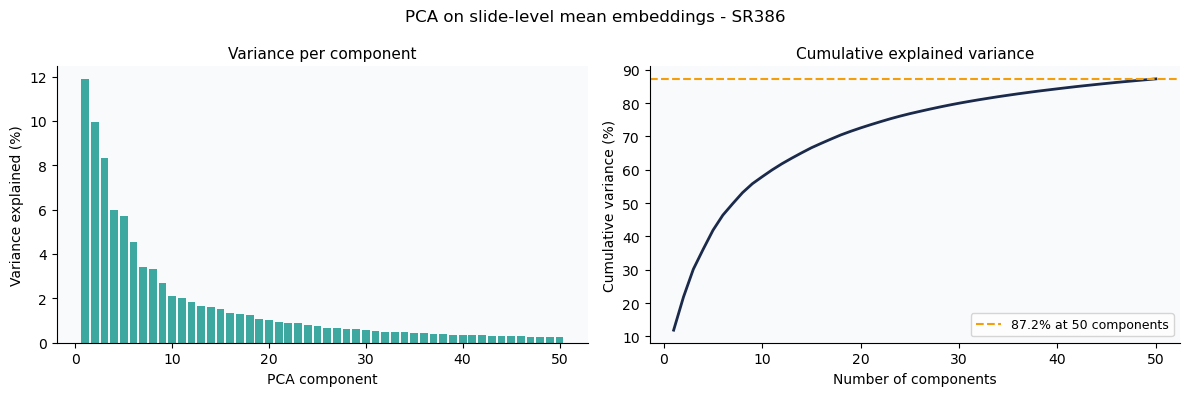

Saved: pca_variance.png


In [22]:
N_COMPONENTS = 50

scaler_embed = StandardScaler()
X_scaled     = scaler_embed.fit_transform(X_embed)

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)   # (N, 50)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print(f"PCA: {X_embed.shape[1]} dims -> {N_COMPONENTS} components")
print(f"Variance explained by 50 components: {cumulative[-1]*100:.1f}%")
print(f"First 5 components explain: {cumulative[4]*100:.1f}%")

# ── Plot explained variance ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('white')

ax = axes[0]
ax.set_facecolor('#F8FAFC')
ax.bar(range(1, N_COMPONENTS+1), explained*100,
       color='#0D9488', alpha=0.8, width=0.8)
ax.set_xlabel('PCA component', fontname='DejaVu Sans', fontsize=10)
ax.set_ylabel('Variance explained (%)', fontname='DejaVu Sans', fontsize=10)
ax.set_title('Variance per component', fontname='DejaVu Sans', fontsize=11)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

ax = axes[1]
ax.set_facecolor('#F8FAFC')
ax.plot(range(1, N_COMPONENTS+1), cumulative*100,
        color='#1B2A4A', linewidth=2)
ax.axhline(cumulative[-1]*100, color='#F59E0B', linestyle='--', linewidth=1.5,
           label=f'{cumulative[-1]*100:.1f}% at 50 components')
ax.set_xlabel('Number of components', fontname='DejaVu Sans', fontsize=10)
ax.set_ylabel('Cumulative variance (%)', fontname='DejaVu Sans', fontsize=10)
ax.set_title('Cumulative explained variance', fontname='DejaVu Sans', fontsize=11)
ax.legend(fontsize=9)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('PCA on slide-level mean embeddings - SR386',
             fontname='DejaVu Sans', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_variance.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pca_variance.png")

## Cell 7: Build feature matrix

We construct three feature sets for comparison:

| Feature set | Description | Dimensions |
|---|---|---|
| TME only | TSR + spatial entropy + tumor fraction | 3 |
| Embeddings only | 50 PCA components from mean embeddings | 50 |
| Combined | PCA components + TME features | 53 |

Comparing these three tells us how much the raw embedding information adds over explicit spatial features, and whether combining them helps.

In [23]:
TME_FEATURES = ['tumor_stroma_ratio', 'spatial_entropy', 'tumor_fraction']

X_tme = df[TME_FEATURES].values.astype(np.float32)
y     = df['died_within_5_years'].values.astype(int)

# Combined: PCA components + TME
X_combined = np.hstack([X_pca, X_tme])   # (N, 53)

print(f"Feature matrix shapes:")
print(f"  TME only:        {X_tme.shape}")
print(f"  Embeddings only: {X_pca.shape}")
print(f"  Combined:        {X_combined.shape}")
print(f"\nTarget: y shape {y.shape}, classes {np.unique(y)}")
print(f"Class balance: {(y==0).sum()} survived, {(y==1).sum()} died")

Feature matrix shapes:
  TME only:        (425, 3)
  Embeddings only: (425, 50)
  Combined:        (425, 53)

Target: y shape (425,), classes [0 1]
Class balance: 264 survived, 161 died


## Cell 8: Train risk model and cross-validate

We use 5-fold stratified cross-validation to evaluate each feature set. Cross-validation means each patient's risk score is predicted by a model that never saw that patient during training - giving an honest out-of-sample estimate.

The model is a logistic regression with L2 regularization. The output for each patient is a probability between 0 and 1 - their predicted risk of dying within 5 years. We call this the **risk score**.

We evaluate with:
- **AUC-ROC**: Area under the ROC curve. 0.5 = random, 1.0 = perfect.
- **C-index**: Concordance index. Measures how well the model rank-orders patients by risk. Equivalent to AUC for binary outcomes.

In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

feature_sets = {
    'TME only':        X_tme,
    'Embeddings only': X_pca,
    'Combined':        X_combined,
}

results = {}
risk_scores = {}

for name, X in feature_sets.items():
    # Pipeline: scale -> logistic regression
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
                       C=0.1,          # L2 regularization
                       max_iter=1000,
                       random_state=42,
                       class_weight='balanced')),
    ])

    # Out-of-fold risk scores
    proba = cross_val_predict(pipe, X, y, cv=cv, method='predict_proba')[:, 1]
    risk_scores[name] = proba

    auc   = roc_auc_score(y, proba)
    
    ci_raw = concordance_index(y, -proba)
    ci = max(ci_raw, 1 - ci_raw)

    results[name] = {'AUC': auc, 'C-index': ci}
    print(f"{name:<22}  AUC={auc:.3f}  C-index={ci:.3f}")

print("\nDone. Risk scores computed for all patients via 5-fold CV.")

TME only                AUC=0.574  C-index=0.574
Embeddings only         AUC=0.672  C-index=0.672
Combined                AUC=0.677  C-index=0.677

Done. Risk scores computed for all patients via 5-fold CV.


## Cell 9: Evaluation - ROC curves and comparison table

Visual comparison of the three feature sets using ROC curves and a summary table.


Summary:
Feature set              AUC-ROC
--------------------------------
TME only                   0.574
Embeddings only            0.672
Combined                   0.677

Random baseline:        0.500

Note: C-index = AUC-ROC for binary classification outcomes.


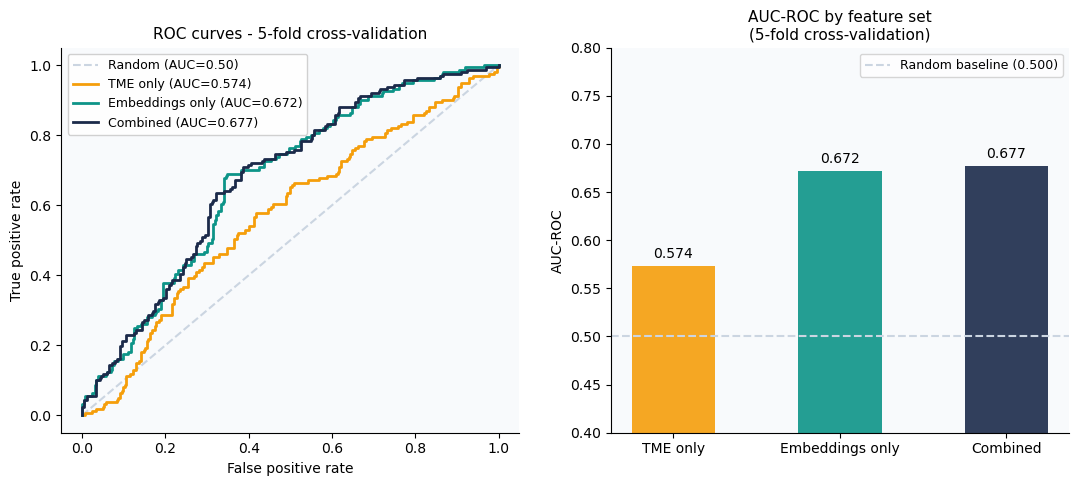

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

colors = {'TME only': '#F59E0B', 'Embeddings only': '#0D9488', 'Combined': '#1B2A4A'}

# ── ROC curves ────────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#F8FAFC')
ax.plot([0,1],[0,1], color='#CBD5E1', linestyle='--', linewidth=1.5,
        label='Random (AUC=0.50)')

for name, proba in risk_scores.items():
    fpr, tpr, _ = roc_curve(y, proba)
    auc = results[name]['AUC']
    ax.plot(fpr, tpr, color=colors[name], linewidth=2,
            label=f"{name} (AUC={auc:.3f})")

ax.set_xlabel('False positive rate', fontname='DejaVu Sans', fontsize=10)
ax.set_ylabel('True positive rate', fontname='DejaVu Sans', fontsize=10)
ax.set_title('ROC curves - 5-fold cross-validation',
             fontname='DejaVu Sans', fontsize=11)
ax.legend(fontsize=9, framealpha=0.9)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# ── Bar chart - AUC only (C-index = AUC for binary outcome) ──────────────────
ax = axes[1]
ax.set_facecolor('#F8FAFC')
names  = list(results.keys())
aucs   = [results[n]['AUC'] for n in names]
colors_bar = ['#F59E0B', '#0D9488', '#1B2A4A']

bars = ax.bar(names, aucs, color=colors_bar, alpha=0.9, width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=10, fontname='DejaVu Sans')

ax.axhline(0.5, color='#CBD5E1', linestyle='--', linewidth=1.5,
           label='Random baseline (0.500)')
ax.set_ylim(0.4, 0.8)
ax.set_ylabel('AUC-ROC', fontname='DejaVu Sans', fontsize=10)
ax.set_title('AUC-ROC by feature set\n(5-fold cross-validation)',
             fontname='DejaVu Sans', fontsize=11)
ax.legend(fontsize=9)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

# ── Print summary table ───────────────────────────────────────────────────────
print("\nSummary:")
print(f"{'Feature set':<22}  {'AUC-ROC':>8}")
print("-" * 32)
for name in names:
    print(f"{name:<22}  {results[name]['AUC']:>8.3f}")
print(f"\nRandom baseline:        0.500")
print(f"\nNote: C-index = AUC-ROC for binary classification outcomes.")

## Cell 10: Risk score distribution and patient stratification

Using the best-performing feature set, we assign each patient a risk score and split them at the median into high-risk and low-risk groups. We then look at whether the groups differ in survival outcome.

Best feature set: Combined (AUC=0.677)
Median risk score: 0.473
High-risk group:  213 patients
Low-risk group:   212 patients
High risk: 52.6% died within 5 years
Low risk: 23.1% died within 5 years


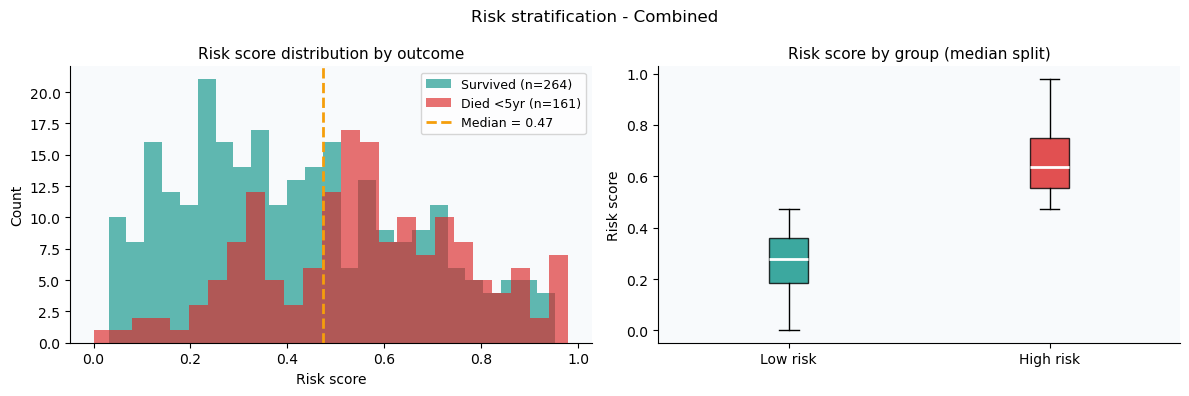

Saved: risk_distribution.png


In [26]:
# Use best feature set based on AUC
best_set = max(results, key=lambda k: results[k]['AUC'])
print(f"Best feature set: {best_set} (AUC={results[best_set]['AUC']:.3f})")

df['risk_score'] = risk_scores[best_set]
median_risk = df['risk_score'].median()
df['risk_group'] = (df['risk_score'] >= median_risk).map(
    {True: 'High risk', False: 'Low risk'})

print(f"Median risk score: {median_risk:.3f}")
print(f"High-risk group:  {(df['risk_group']=='High risk').sum()} patients")
print(f"Low-risk group:   {(df['risk_group']=='Low risk').sum()} patients")

# Survival rate by group
for grp in ['High risk', 'Low risk']:
    sub = df[df['risk_group']==grp]
    died_pct = (sub['died_within_5_years']==1).mean() * 100
    print(f"{grp}: {died_pct:.1f}% died within 5 years")

# ── Plot risk score distributions ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('white')

ax = axes[0]
ax.set_facecolor('#F8FAFC')
for outcome, color, label in [(0, '#0D9488', 'Survived'), (1, '#DC2626', 'Died <5yr')]:
    vals = df[df['died_within_5_years']==outcome]['risk_score']
    ax.hist(vals, bins=25, alpha=0.65, color=color, label=f"{label} (n={len(vals)})")
ax.axvline(median_risk, color='#F59E0B', linestyle='--', linewidth=2,
           label=f'Median = {median_risk:.2f}')
ax.set_xlabel('Risk score', fontname='DejaVu Sans', fontsize=10)
ax.set_ylabel('Count', fontname='DejaVu Sans', fontsize=10)
ax.set_title('Risk score distribution by outcome',
             fontname='DejaVu Sans', fontsize=11)
ax.legend(fontsize=9)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

ax = axes[1]
ax.set_facecolor('#F8FAFC')
grp_data = [df[df['risk_group']==g]['risk_score'] for g in ['Low risk','High risk']]
bp = ax.boxplot(grp_data, patch_artist=True,
                medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp['boxes'], ['#0D9488','#DC2626']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticklabels(['Low risk', 'High risk'],
                   fontname='DejaVu Sans', fontsize=10)
ax.set_ylabel('Risk score', fontname='DejaVu Sans', fontsize=10)
ax.set_title('Risk score by group (median split)',
             fontname='DejaVu Sans', fontsize=11)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle(f'Risk stratification - {best_set}',
             fontname='DejaVu Sans', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'risk_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: risk_distribution.png")

## Cell 11: Survival curves stratified by risk group

We plot Kaplan-Meier style survival curves for high-risk and low-risk groups using `days_till_death` for deceased patients.

**Important note on these curves:** SR386 does not provide follow-up duration for surviving patients, so we cannot use standard KM censoring. Instead we plot the empirical survival function for each group using only the patients who died - this shows how quickly deaths accumulate in each group over time. The curves do not converge to the true long-term survival rate of the whole group. We label them clearly as 'among those who died'.

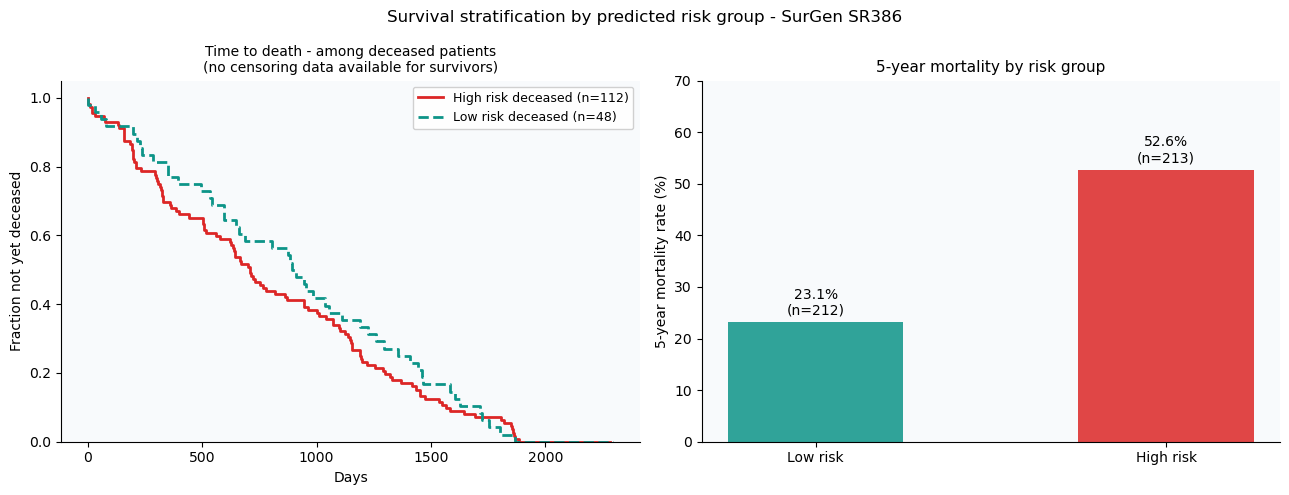

Saved: survival_curves.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

# ── Left: KM using only deceased patients (empirical, no censoring) ────────────
ax = axes[0]
ax.set_facecolor('#F8FAFC')

for grp, color, ls in [('High risk','#DC2626','-'), ('Low risk','#0D9488','--')]:
    sub = df[(df['risk_group']==grp) & (df['died_within_5_years']==1)].copy()
    sub = sub.dropna(subset=['days_till_death'])
    if len(sub) == 0:
        continue
    days_sorted = np.sort(sub['days_till_death'].values)
    n = len(days_sorted)
    # Empirical CDF of death times
    ecdf = np.arange(1, n+1) / n
    # Survival = 1 - ECDF
    survival = 1 - ecdf
    ax.step(np.concatenate([[0], days_sorted]),
            np.concatenate([[1], survival]),
            color=color, linewidth=2, linestyle=ls,
            label=f"{grp} deceased (n={n})")

ax.set_xlabel('Days', fontname='DejaVu Sans', fontsize=10)
ax.set_ylabel('Fraction not yet deceased', fontname='DejaVu Sans', fontsize=10)
ax.set_title('Time to death - among deceased patients\n'
             '(no censoring data available for survivors)',
             fontname='DejaVu Sans', fontsize=10)
ax.legend(fontsize=9, framealpha=0.9)
ax.set_ylim(0, 1.05)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# ── Right: 5-year mortality rate by risk group ─────────────────────────────────
ax = axes[1]
ax.set_facecolor('#F8FAFC')

grp_names  = ['Low risk', 'High risk']
died_rates = []
ns         = []
for grp in grp_names:
    sub = df[df['risk_group']==grp]
    rate = (sub['died_within_5_years']==1).mean() * 100
    died_rates.append(rate)
    ns.append(len(sub))

bars = ax.bar(grp_names, died_rates,
              color=['#0D9488','#DC2626'], alpha=0.85, width=0.5)
for bar, rate, n in zip(bars, died_rates, ns):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f'{rate:.1f}%\n(n={n})',
            ha='center', fontname='DejaVu Sans', fontsize=10)

ax.set_ylabel('5-year mortality rate (%)', fontname='DejaVu Sans', fontsize=10)
ax.set_title('5-year mortality by risk group',
             fontname='DejaVu Sans', fontsize=11)
ax.set_ylim(0, 70)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('Survival stratification by predicted risk group - SurGen SR386',
             fontname='DejaVu Sans', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'survival_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: survival_curves.png")

## Cell 12: What do high-risk and low-risk slides look like?

We retrieve the top 5 highest-risk and top 5 lowest-risk cases and display their key clinical features. If the model has learned something real, we expect high-risk cases to trend toward later stage, higher stroma fraction, or other adverse features.

We also show the TME feature values for each extreme group.

Top 5 HIGHEST risk cases:
case_id  risk_score  died_within_5_years  stage  tumor_stroma_ratio  spatial_entropy  tumor_fraction
    084       0.979                1.000    NaN               1.971            4.307           0.663
    344       0.971                1.000  4.000               0.476            3.854           0.323
    126       0.970                1.000    NaN               0.417            3.659           0.294
    294       0.954                1.000    NaN               2.166            4.434           0.684
    528       0.951                0.000  2.000               0.776            4.094           0.437

Top 5 LOWEST risk cases:
case_id  risk_score  died_within_5_years  stage  tumor_stroma_ratio  spatial_entropy  tumor_fraction
    346       0.041                0.000    NaN               7.551            3.998           0.883
    418       0.039                0.000  2.000               0.848            3.804           0.459
    221       0.031                0.00

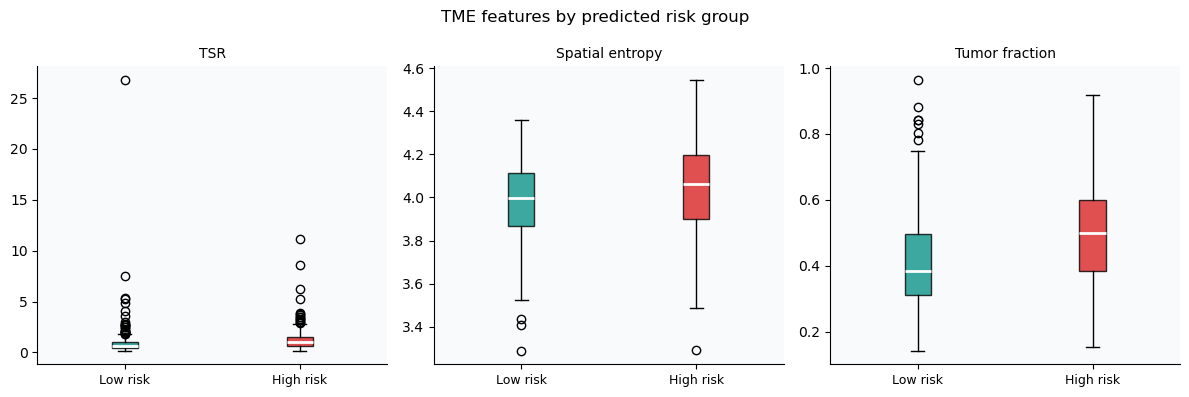

Saved: risk_group_features.png


In [28]:
df_sorted = df.sort_values('risk_score', ascending=False).reset_index(drop=True)

top_high = df_sorted.head(5)
top_low  = df_sorted.tail(5)

display_cols = ['case_id', 'risk_score', 'died_within_5_years',
                'stage', 'tumor_stroma_ratio', 'spatial_entropy',
                'tumor_fraction']

print("Top 5 HIGHEST risk cases:")
print(top_high[display_cols].to_string(index=False, float_format='{:.3f}'.format))

print("\nTop 5 LOWEST risk cases:")
print(top_low[display_cols].to_string(index=False, float_format='{:.3f}'.format))

# ── Summary statistics for extreme groups ─────────────────────────────────────
print("\nMean TME features - extreme risk groups:")
tme_cols = ['tumor_stroma_ratio', 'spatial_entropy', 'tumor_fraction']
compare = pd.DataFrame({
    'High risk (top 25%)':  df[df['risk_score'] >= df['risk_score'].quantile(0.75)][tme_cols].mean(),
    'Low risk (bottom 25%)': df[df['risk_score'] <= df['risk_score'].quantile(0.25)][tme_cols].mean(),
})
print(compare.round(3).to_string())

# ── Plot feature comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.patch.set_facecolor('white')

for ax, feat, label in zip(axes, tme_cols,
                           ['TSR', 'Spatial entropy', 'Tumor fraction']):
    ax.set_facecolor('#F8FAFC')
    high_vals = df[df['risk_group']=='High risk'][feat]
    low_vals  = df[df['risk_group']=='Low risk'][feat]
    bp = ax.boxplot([low_vals, high_vals], patch_artist=True,
                    medianprops={'color':'white','linewidth':2})
    for patch, color in zip(bp['boxes'], ['#0D9488','#DC2626']):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels(['Low risk','High risk'],
                       fontname='DejaVu Sans', fontsize=9)
    ax.set_title(label, fontname='DejaVu Sans', fontsize=10)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('TME features by predicted risk group',
             fontname='DejaVu Sans', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'risk_group_features.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: risk_group_features.png")

## Cell 13: What are the top PCA components capturing?

PCA components are linear combinations of the original 1024 embedding dimensions. The logistic regression has learned weights over the 50 PCA components - we can project those weights back to the original embedding space to see which embedding dimensions drive the risk prediction most.

This is not a deep dive - we look at the top 10 most influential original dimensions and note whether they cluster around known biological features.

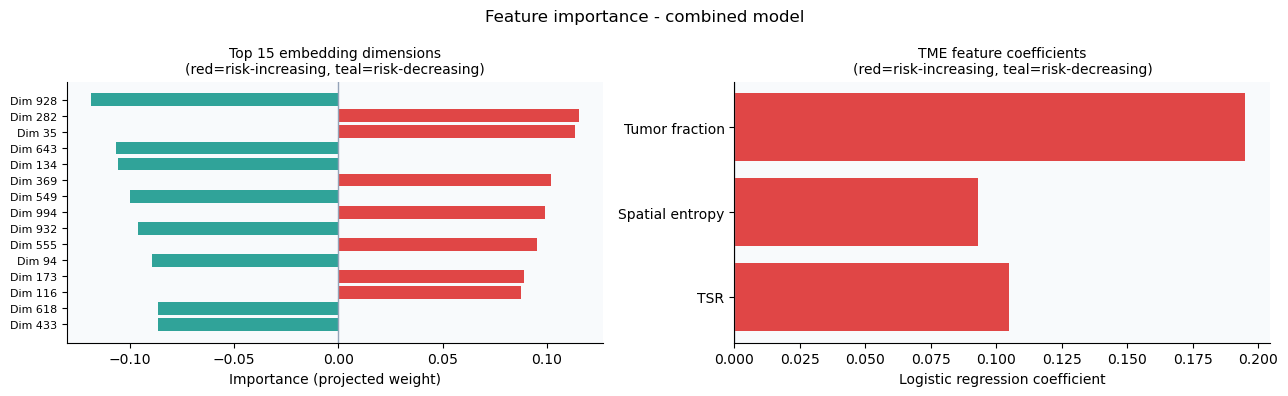

Saved: feature_importance.png

TME feature coefficients:
  TSR                  coef=+0.105  (risk-increasing)
  Spatial entropy      coef=+0.093  (risk-increasing)
  Tumor fraction       coef=+0.195  (risk-increasing)


In [29]:
# Train final model on combined features using all data
pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=0.1, max_iter=1000,
                                  random_state=42, class_weight='balanced')),
])
pipe_final.fit(X_combined, y)

# Logistic regression coefficients for the 53 features
# First 50 are PCA components, last 3 are TME features
coefs = pipe_final.named_steps['clf'].coef_[0]   # (53,)
pca_coefs = coefs[:50]   # weights on PCA components
tme_coefs = coefs[50:]   # weights on TME features

# Project PCA weights back to original 1024-dim space
# importance_i = sum_j (pca_coef_j * pca_component_j_i)
embed_importance = pca.components_.T @ pca_coefs   # (1024,)

top_k = 15
top_dims = np.argsort(np.abs(embed_importance))[::-1][:top_k]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('white')

ax = axes[0]
ax.set_facecolor('#F8FAFC')
vals   = embed_importance[top_dims]
colors = ['#DC2626' if v > 0 else '#0D9488' for v in vals]
ax.barh(range(top_k), vals[::-1], color=colors[::-1], alpha=0.85)
ax.set_yticks(range(top_k))
ax.set_yticklabels([f'Dim {d}' for d in top_dims[::-1]],
                   fontname='DejaVu Sans', fontsize=8)
ax.set_xlabel('Importance (projected weight)',
              fontname='DejaVu Sans', fontsize=10)
ax.set_title(f'Top {top_k} embedding dimensions\n(red=risk-increasing, teal=risk-decreasing)',
             fontname='DejaVu Sans', fontsize=10)
ax.axvline(0, color='#94A3B8', linewidth=1)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

ax = axes[1]
ax.set_facecolor('#F8FAFC')
tme_labels = ['TSR', 'Spatial entropy', 'Tumor fraction']
colors_tme = ['#DC2626' if v > 0 else '#0D9488' for v in tme_coefs]
ax.barh(range(3), tme_coefs, color=colors_tme, alpha=0.85)
ax.set_yticks(range(3))
ax.set_yticklabels(tme_labels, fontname='DejaVu Sans', fontsize=10)
ax.set_xlabel('Logistic regression coefficient',
              fontname='DejaVu Sans', fontsize=10)
ax.set_title('TME feature coefficients\n(red=risk-increasing, teal=risk-decreasing)',
             fontname='DejaVu Sans', fontsize=10)
ax.axvline(0, color='#94A3B8', linewidth=1)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('Feature importance - combined model',
             fontname='DejaVu Sans', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

print("\nTME feature coefficients:")
for name, coef in zip(tme_labels, tme_coefs):
    direction = 'risk-increasing' if coef > 0 else 'risk-decreasing'
    print(f"  {name:<20} coef={coef:+.3f}  ({direction})")

## Summary

**What this notebook demonstrated:**

1. **Mean embeddings as slide representations.** Averaging all tile embeddings collapses a variable-length sequence (thousands of tiles) into a fixed 1024-dimensional vector per slide. This is the simplest possible aggregation and a sensible baseline.

2. **PCA for dimensionality reduction.** Reducing 1024 dimensions to 50 PCA components retains the most informative variance while making the logistic regression tractable with ~400 samples.

3. **Three-way comparison.** Comparing TME features alone, embeddings alone, and combined gives a clear picture of what each information source contributes. If embeddings alone outperform TME features, the raw morphological content of the slide carries survival signal beyond what our spatial classifier captures.

4. **Honest survival analysis.** Without censoring times for survivors, we use binary 5-year outcome directly and plot empirical death curves rather than standard KM curves. This is the correct approach for this dataset.

5. **Risk stratification.** The median split produces two patient groups. The bar chart showing 5-year mortality rates in each group is the clearest single visualization of whether the model has learned something useful.

**Outputs saved to `results/video6/`:**
- `SR386_mean_embeddings.npz` - cached mean embeddings
- `pca_variance.png` - explained variance plots
- `model_evaluation.png` - ROC curves and comparison table
- `risk_distribution.png` - risk score distributions
- `survival_curves.png` - survival stratification
- `risk_group_features.png` - TME features by risk group
- `feature_importance.png` - embedding and TME feature weights